# Task 1 - Logistic Regression

Dans ce notebook, nous allons implémenter un modèle de régression logistique, un algorithme fondamental pour les problèmes de classification binaire en machine learning supervisé.

In [18]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
%matplotlib inline
#plt.style.use('seaborn')

## 1. Chargement et exploration des données

Pour cette démonstration, nous utiliserons le jeu de données du cancer du sein de Wisconsin, qui est un problème de classification binaire classique.

In [19]:
from sklearn.datasets import load_breast_cancer

# Chargement des données du cancer du sein de Wisconsin
breast_cancer = load_breast_cancer()

# Création d'un DataFrame pandas
df = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [20]:
# Exploration des données
print("Shape of dataset:", df.shape)
print("\nInfo of dataset:")
df.info()

Shape of dataset: (569, 31)

Info of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-n

In [21]:
# Statistiques descriptives
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Variable cible: target

Distribution des classes:
target
1    357
0    212
Name: count, dtype: int64


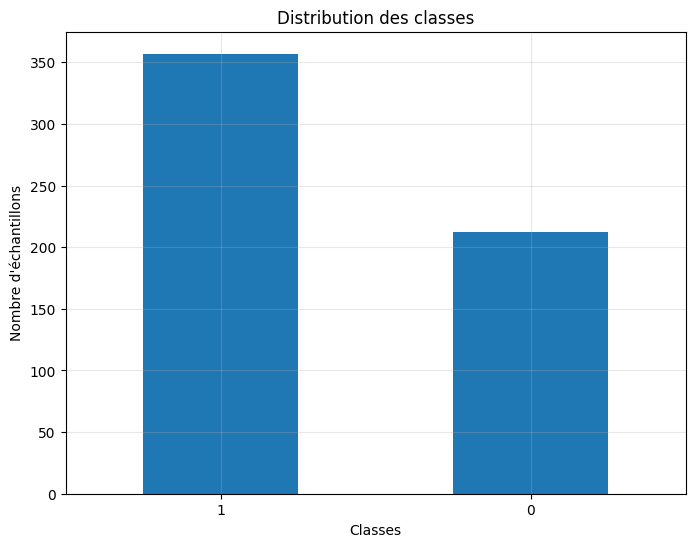

In [22]:
# Vérification de la distribution des classes (variable cible)
target_column = df.columns[-1]
print(f"Variable cible: {target_column}")
print("\nDistribution des classes:")
print(df[target_column].value_counts())

# Visualisation de la distribution des classes
plt.figure(figsize=(8, 6))
df[target_column].value_counts().plot(kind='bar')
plt.title('Distribution des classes')
plt.xlabel('Classes')
plt.ylabel('Nombre d\'échantillons')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

## 2. Prétraitement des données

Séparation des caractéristiques (features) et de la variable cible, puis normalisation des données.

In [23]:
# Séparation des caractéristiques (features) et de la variable cible
X = df.iloc[:, :-1]  # Toutes les colonnes sauf la dernière
y = df.iloc[:, -1]   # Dernière colonne (variable cible)

print(f"Dimensions des caractéristiques: {X.shape}")
print(f"Dimensions de la variable cible: {y.shape}")

Dimensions des caractéristiques: (569, 30)
Dimensions de la variable cible: (569,)


In [24]:
# Normalisation des données (recommandée pour la régression logistique)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir en DataFrame pour faciliter la manipulation
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Données après normalisation:")
X_scaled.head()

Données après normalisation:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## 3. Division des données

Division des données en ensembles d'entraînement et de test.

In [25]:
# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape}")
print(f"Taille de l'ensemble de test: {X_test.shape}")

Taille de l'ensemble d'entraînement: (455, 30)
Taille de l'ensemble de test: (114, 30)


## 4. Entraînement du modèle

Création et entraînement du modèle de régression logistique.

In [26]:
# Création et entraînement du modèle de régression logistique
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## 5. Prédiction et évaluation du modèle

Prédiction sur l'ensemble de test et évaluation des performances du modèle.

In [27]:
# Prédiction sur l'ensemble de test
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]  # Probabilités pour la classe positive

# Affichage des premières prédictions
results_df = pd.DataFrame({'Valeurs réelles': y_test, 'Prédictions': y_pred, 'Probabilités': y_pred_proba})
print("Comparaison des valeurs réelles et prédites:")
print(results_df.head(10))

Comparaison des valeurs réelles et prédites:
     Valeurs réelles  Prédictions  Probabilités
256                0            0  6.796842e-08
428                1            1  9.999885e-01
501                0            0  6.642570e-03
363                1            1  5.399288e-01
564                0            0  7.694098e-10
464                1            1  9.922998e-01
358                1            1  9.999825e-01
343                0            0  5.556609e-07
516                0            0  5.804957e-05
567                0            0  8.388550e-11


In [28]:
# Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle: {accuracy:.4f}")

# Rapport de classification détaillé
print("\nRapport de classification:")
print(classification_report(y_test, y_pred))

Précision du modèle: 0.9825

Rapport de classification:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



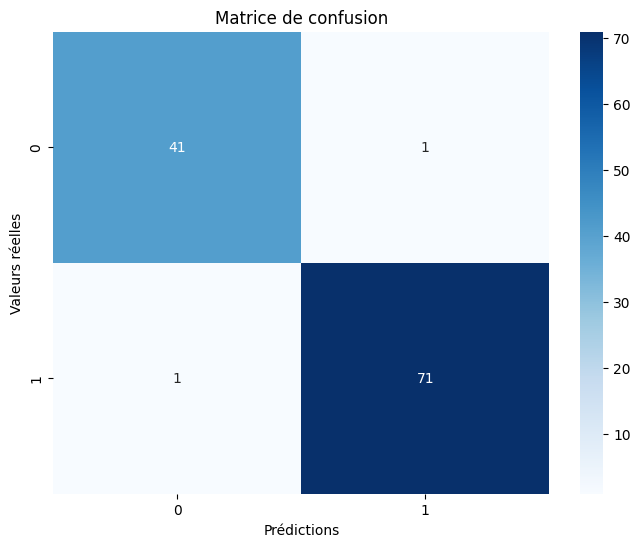

In [29]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.show()

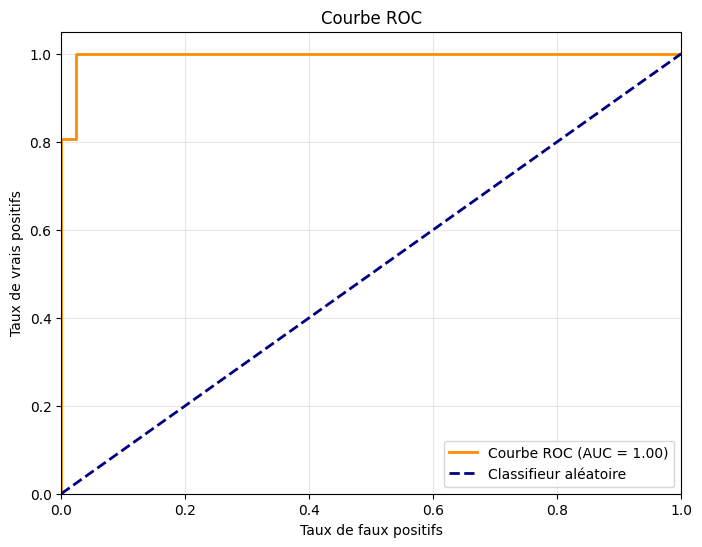

Aire sous la courbe ROC (AUC): 0.9954


In [30]:
# Courbe ROC et AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classifieur aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Aire sous la courbe ROC (AUC): {roc_auc:.4f}")

## 6. Interprétation des coefficients

Analyse des coefficients du modèle pour comprendre l'importance des caractéristiques.

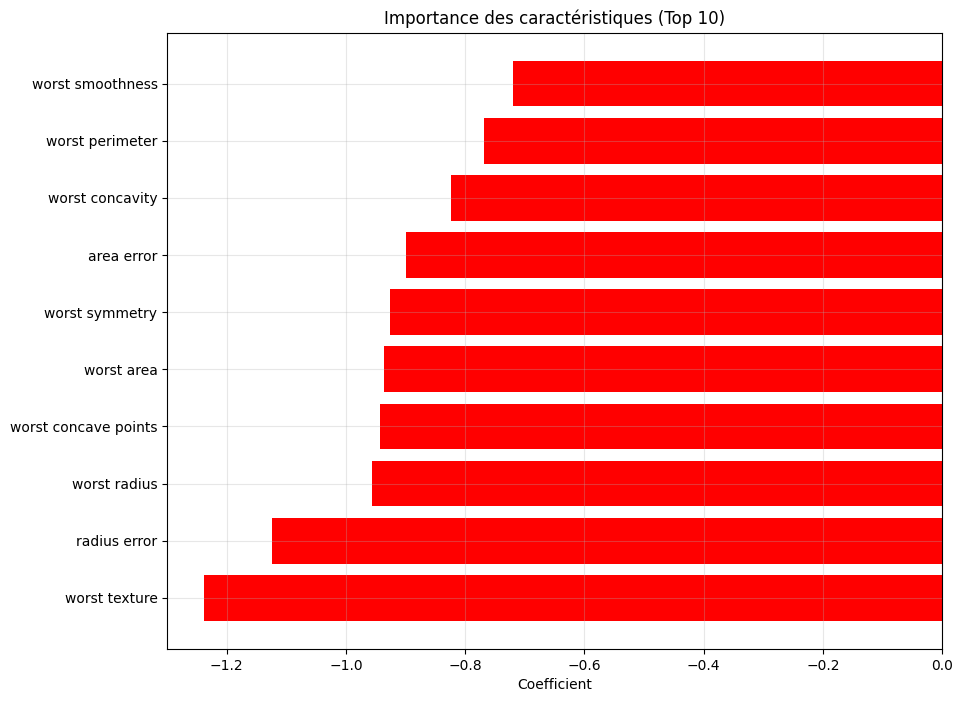

Caractéristiques les plus influentes:
                 Feature  Coefficient
21         worst texture    -1.237688
10          radius error    -1.123324
20          worst radius    -0.956331
27  worst concave points    -0.942609
23            worst area    -0.935964
28        worst symmetry    -0.925231
13            area error    -0.899034
26       worst concavity    -0.823374
22       worst perimeter    -0.767970
24      worst smoothness    -0.719987


In [31]:
# Création d'un DataFrame pour les coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
})

# Tri par valeur absolue des coefficients
coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

# Visualisation des 10 caractéristiques les plus importantes
plt.figure(figsize=(10, 8))
top_features = coefficients.head(10)
colors = ['red' if x < 0 else 'blue' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient')
plt.title('Importance des caractéristiques (Top 10)')
plt.grid(True, alpha=0.3)
plt.show()

print("Caractéristiques les plus influentes:")
print(coefficients[['Feature', 'Coefficient']].head(10))

## Conclusion

Dans ce notebook, nous avons implémenté un modèle de régression logistique :
- Chargement et exploration des données du cancer du sein
- Prétraitement des données (normalisation)
- Division des données en ensembles d'entraînement et de test
- Entraînement du modèle de régression logistique
- Évaluation du modèle avec plusieurs métriques (précision, rappel, F1-score, AUC)
- Visualisation des résultats (matrice de confusion, courbe ROC)
- Interprétation des coefficients pour comprendre l'importance des caractéristiques

La régression logistique est un excellent point de départ pour les problèmes de classification binaire. Elle est facile à interpréter et fournit des probabilités bien calibrées pour les prédictions.